# Phase 2: Data Exploration

Explores the combined Ontario Demand + HOEP dataset (2002 - April 30, 2025)
produced by `src/data_ingestion.py`. Goals for this notebook:

1. Load data and check its basic shape/integrity
2. Handle the twice-yearly DST timestamp issue
3. Look at the long-run trend (23 years)
4. Zoom into a single week to see the daily demand shape
5. Overlay demand and price to visually confirm the Surplus Baseload
   Generation (SBG) story behind the $0 HOEP hours
6. Quantify how often HOEP sits at $0, and check for genuine outliers
   (e.g. known grid events) vs. data errors

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 4)

## 1. Load and inspect

Run `src/data_ingestion.py` first (`python src/data_ingestion.py` from the
project root) so that `data/raw/combined_dataset.csv` exists.

The number of total hours (rows) outputted should be **201,624**:

Hours in a non-leap year: 365 * 24 = 8760 \
Hours in leap year: 366 * 24 = 8784

Disregarding the years 2002 and 2025 where there are data gaps at the start and ends of the year, respectively, there are 22 full years to be counted - of which, 6 of them (2004, 2008, 2012, 2016, 2020, 2024) were leap years. 2002 contains 5880 (245 * 24) hours from May through to the end of December, given that the IESO and ECCC use EST all year round. 2025 contains 2880 (120 * 24) hours from January through to the end of April, given that 2025 was not a leap year and, again, IESO and ECCC use EST all year round. 

This renders our total of **201,624** hours: (8760 * 16) + (8784 * 6) + 5880 + 2880 = **201,624**


In [6]:
df = pd.read_csv("../data/raw/combined_dataset.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# Check data types of the columns
print(f"Column Data Types:\n{df.dtypes}")

# Convert 'hoep' column to numeric
df['hoep'] = pd.to_numeric(df['hoep'], errors='coerce')

print(f"Rows: {len(df):,}")
print(f"Date range: {df['datetime'].min()}  to  {df['datetime'].max()}")
print(f"Columns: {list(df.columns)}")
df.head()

Column Data Types:
Date                      object
Hour                       int64
market_demand              int64
ontario_demand             int64
datetime          datetime64[ns]
hoep                      object
temperature_c            float64
dtype: object
Rows: 201,624
Date range: 2002-05-01 00:00:00  to  2025-04-30 23:00:00
Columns: ['Date', 'Hour', 'market_demand', 'ontario_demand', 'datetime', 'hoep', 'temperature_c']


/var/folders/g5/_pf2rt1s6q93qk9_5xy8ztb80000gn/T/ipykernel_23308/3502357833.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/combined_dataset.csv", parse_dates=["datetime"])


,Date,Hour,market_demand,ontario_demand,datetime,hoep,temperature_c
0,2002-05-01,1,14141,14137,2002-05-01 00:00:00,22.97,3.1
1,2002-05-01,2,13876,13872,2002-05-01 01:00:00,23.27,2.5
2,2002-05-01,3,13974,13820,2002-05-01 02:00:00,24.54,1.5
3,2002-05-01,4,13898,13744,2002-05-01 03:00:00,15.17,1.1
4,2002-05-01,5,14378,14224,2002-05-01 04:00:00,23.59,1.1


In [7]:
# Basic integrity checks
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate timestamps:", df['datetime'].duplicated().sum())
print()
print(df[['ontario_demand', 'hoep', 'temperature_c']].describe())

Missing values per column:
Date               0
Hour               0
market_demand      0
ontario_demand     0
datetime           0
hoep               8
temperature_c     53
dtype: int64

Duplicate timestamps: 0

       ontario_demand           hoep  temperature_c
count   201624.000000  201616.000000  201571.000000
mean     16218.359595      33.865462       9.245120
std       2567.354355      32.801773      10.964917
min       2270.000000    -138.790000     -26.000000
25%      14298.000000      14.940000       0.900000
50%      16104.000000      29.830000       9.200000
75%      17993.000000      42.630000      18.500000
max      27005.000000    1660.800000      37.500000


In [ ]:
# Show that the NaN values are a mix of random times and multi-hour stretches where IESO/ECCC did not collect data - not all from one big chunk that would suggest a data ingestion error
print(f"\nInitial Missing Temperatures:")
print(df[df['temperature_c'].isna()][["Date", "Hour", "ontario_demand", "hoep", "temperature_c"]])
print(f"\nInitial Missing HOEPs:")
print(df[df['hoep'].isna()][["Date", "Hour", "ontario_demand", "hoep", "temperature_c"]])

# We will replace these NaN values with an average of the values at that month/day/hour from the other years. We will drop the 3 highest and lowest values prior to calculating
# the mean so as to account for any cold snaps, heatwaves, or other drivers of outliers that would drastically skew the mean
df["month_day_hour"] = df["datetime"].dt.strftime("%m-%d-%H")

# Helper function to calculate the temperature and HOEP means (after removing the 3 highest and lowest)
def calc_vals_mean(vals, temps=False):
    vals = vals.dropna().sort_values()

    if len(vals) > 6:
        vals = vals.iloc[3:-3]

    return vals.mean().round(1) if temps else vals.mean().round(2)


temp_means = df.groupby("month_day_hour")["temperature_c"].apply(lambda x: calc_vals_mean(x, temps=True))
hoep_means = df.groupby("month_day_hour")["hoep"].apply(lambda x: calc_vals_mean(x, temps=False))

# Fill only NaN values
df["temperature_c"] = df["temperature_c"].fillna(df["month_day_hour"].map(temp_means))
df["hoep"] = df["hoep"].fillna(df["month_day_hour"].map(hoep_means))

# Check that no NaN values remain
print(f"\nMissing Temperatures Now:")
print(df[df['temperature_c'].isna()][["Date", "Hour", "ontario_demand", "hoep", "temperature_c"]])
print(f"\nMissing HOEPs Now:")
print(df[df['hoep'].isna()][["Date", "Hour", "ontario_demand", "hoep", "temperature_c"]])

# Remove the helper column
df.drop(columns="month_day_hour", inplace=True)


Initial Missing Temperatures:
              Date  Hour  ontario_demand    hoep  temperature_c
4743    2002-11-14    16           18618   34.96            NaN
7040    2003-02-18     9           21261  148.93            NaN
29301   2005-09-02    22           17319   39.48            NaN
48413   2007-11-08     6           15041   38.83            NaN
55627   2008-09-03    20           22120  101.86            NaN
78573   2011-04-17    22           15628   56.10            NaN
100257  2013-10-07    10           16073   14.14            NaN
100258  2013-10-07    11           16210   14.53            NaN
100259  2013-10-07    12           16177   13.94            NaN
100260  2013-10-07    13           16000   12.19            NaN
100261  2013-10-07    14           15992   12.38            NaN
100262  2013-10-07    15           15982   13.97            NaN
100263  2013-10-07    16           16182   14.30            NaN
100264  2013-10-07    17           16356   13.32            NaN
100265  2

## 2. DST Check

Ontario observes Daylight Saving Time, which would mean one **missing hour** every Spring (skip 2:00 AM to become 3:00 AM) and one **duplicated hour** every Fall (2:00 AM occurs twice). However, the IESO have confirmed they operate using EST all year round so this shouldn't be an issue, however we will perform a check. The output should display no days with more or less than 24 hours.

In [34]:
hours_per_day = df.groupby(df['datetime'].dt.date).size()
irregular_days = hours_per_day[hours_per_day != 24]

print(f"Days with != 24 hourly rows: {len(irregular_days)}")
irregular_days.head(20)

Days with != 24 hourly rows: 0


Series([], dtype: int64)

## 3. Long-run trend (23 years)

Resample to monthly averages to see the big-picture shape: conservation-era
decline, the 2008-09 recession dip, the 2020 COVID collapse, and any
post-pandemic recovery.

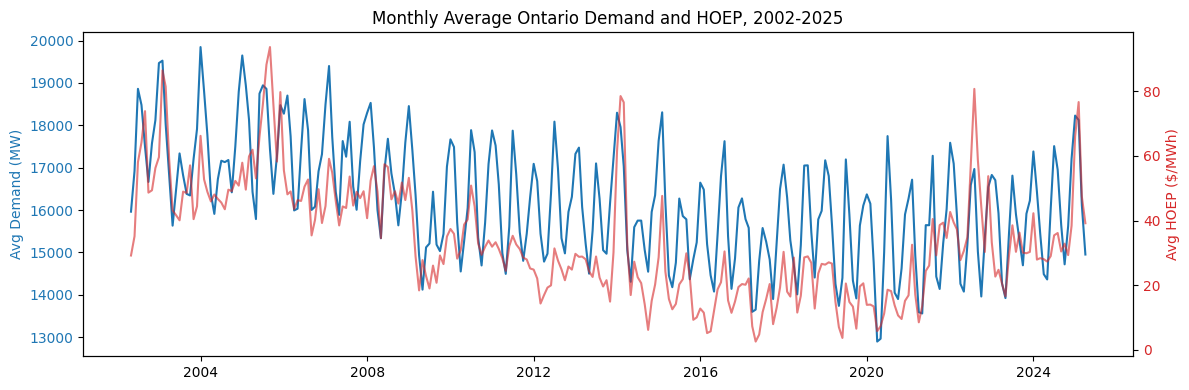

In [35]:
monthly = df.set_index('datetime').resample('MS').agg(
    avg_demand=('ontario_demand', 'mean'),
    avg_price=('hoep', 'mean'),
)

fig, ax1 = plt.subplots()
ax1.plot(monthly.index, monthly['avg_demand'], color='tab:blue', label='Avg Ontario Demand (MW)')
ax1.set_ylabel('Avg Demand (MW)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly['avg_price'], color='tab:red', alpha=0.6, label='Avg HOEP ($/MWh)')
ax2.set_ylabel('Avg HOEP ($/MWh)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Monthly Average Ontario Demand and HOEP, 2002-2025')
fig.tight_layout()
plt.show()

## 4. Zoom into a single week

Pick an arbitrary mid-year week to see the daily double-peak shape
(morning ramp + evening peak) and the weekday/weekend contrast.
Adjust the date range below to any week you like.

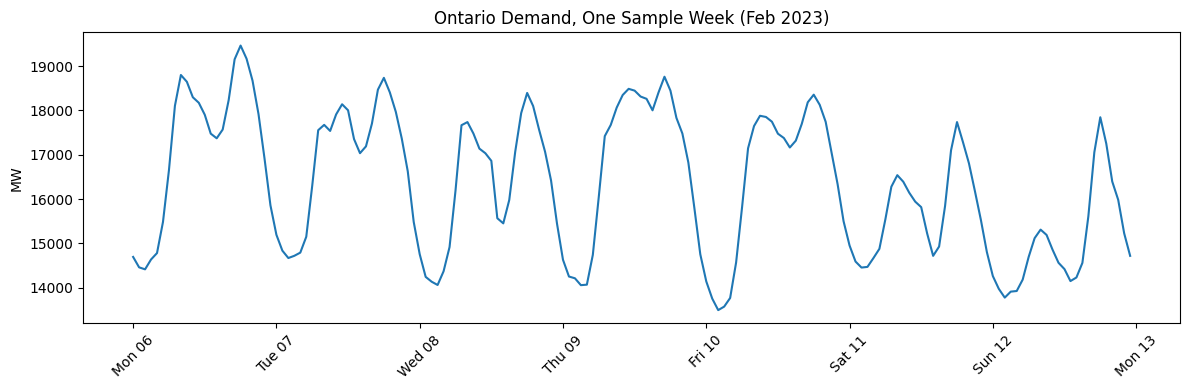

In [36]:
week = df[(df['datetime'] >= '2023-02-06') & (df['datetime'] < '2023-02-13')]

fig, ax = plt.subplots()
ax.plot(week['datetime'], week['ontario_demand'])
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
plt.title('Ontario Demand, One Sample Week (Feb 2023)')
plt.ylabel('MW')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Demand vs. price overlay -- checking the SBG story

Surplus Baseload Generation (SBG) means $0 HOEP hours should cluster during
low-demand periods -- overnight, and in low-demand shoulder-season months
(spring/fall) when nuclear and hydro baseload output exceeds Ontario demand.
Let's check this against the actual data rather than just taking it on faith.

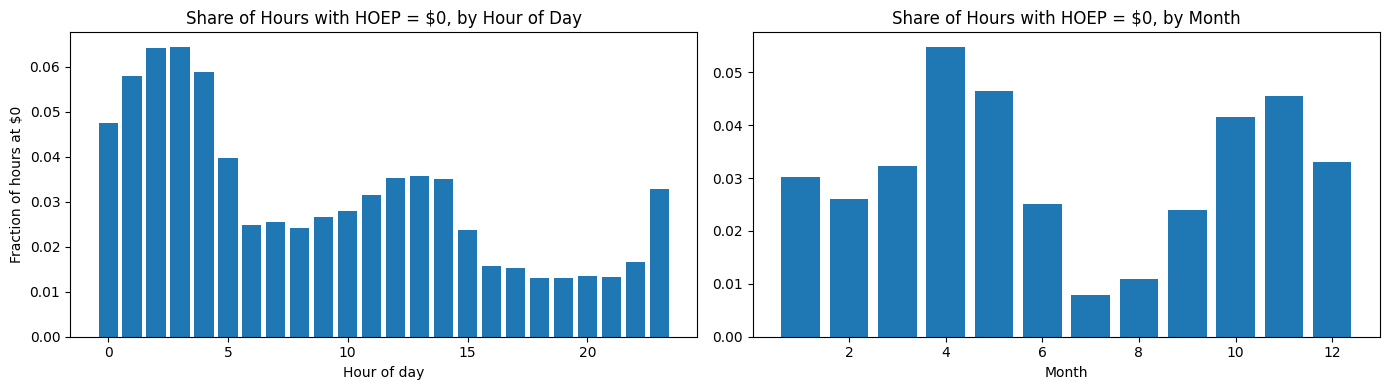

In [37]:
df['is_zero_price'] = df['hoep'] == 0
df['hour_of_day'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

zero_by_hour = df.groupby('hour_of_day')['is_zero_price'].mean()
zero_by_month = df.groupby('month')['is_zero_price'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(zero_by_hour.index, zero_by_hour.values)
axes[0].set_title('Share of Hours with HOEP = $0, by Hour of Day')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Fraction of hours at $0')

axes[1].bar(zero_by_month.index, zero_by_month.values)
axes[1].set_title('Share of Hours with HOEP = $0, by Month')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

If the SBG explanation holds, you should see the left chart peak overnight
(roughly hours 0-6) and the right chart peak in shoulder-season months
(around March-May and September-November) -- exactly when demand is
lowest relative to nuclear/hydro baseload output.

## 6. Quantify $0 HOEP overall, and check for other outliers

First, the overall $0 rate and how it's trended year over year (SBG became
more common over time as more wind/nuclear came online and demand growth
slowed). Then a basic outlier scan on price to catch genuine extreme events
(e.g. real grid emergencies) versus potential data errors. None of the outliers
are impossible values, all likely a result of a supply-side constraint and 
several are clustered around multi-hour/multi-day timeframes which suggest real
events as opposed to data errors.

Overall share of hours at HOEP = $0: 3.15%


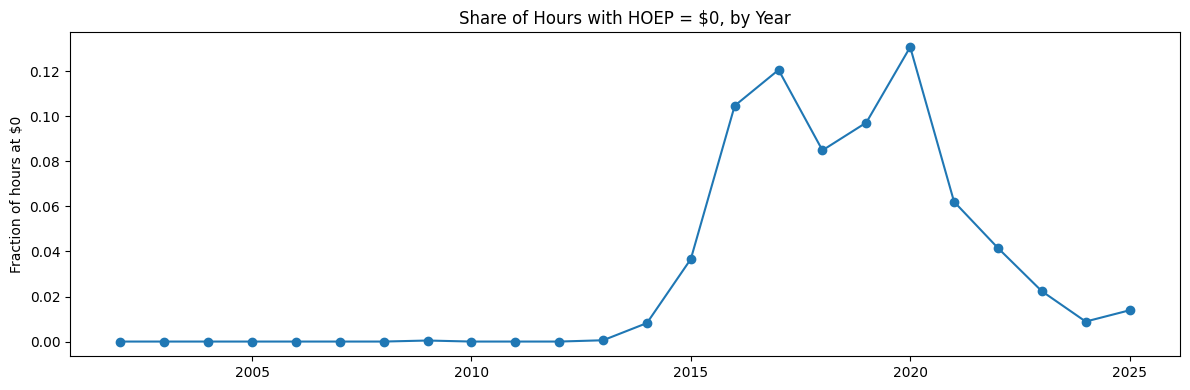

In [38]:
zero_rate_overall = df['is_zero_price'].mean()
print(f"Overall share of hours at HOEP = $0: {zero_rate_overall:.2%}")

zero_by_year = df.groupby('year')['is_zero_price'].mean()
fig, ax = plt.subplots()
ax.plot(zero_by_year.index, zero_by_year.values, marker='o')
plt.title('Share of Hours with HOEP = $0, by Year')
plt.ylabel('Fraction of hours at $0')
plt.tight_layout()
plt.show()

In [39]:
# Check for hours where price is many standard deviations from the mean.
price_mean, price_std = df['hoep'].mean(), df['hoep'].std()
outliers = df[(df['hoep'] - price_mean).abs() > 6 * price_std]

print(f"Rows flagged as extreme outliers (>6 std from mean): {len(outliers)}")
outliers[['datetime', 'hoep', 'ontario_demand']].sort_values('hoep', ascending=False).head(20)

Rows flagged as extreme outliers (>6 std from mean): 453


,datetime,hoep,ontario_demand
165753,2021-03-28 09:00:00,1660.80,14682
123691,2016-06-09 19:00:00,1619.60,15787
199547,2025-02-03 11:00:00,1476.34,20176
195663,2024-08-25 15:00:00,1394.13,20150
199306,2025-01-24 10:00:00,1370.53,20346
123692,2016-06-09 20:00:00,1327.89,15826
155287,2020-01-17 07:00:00,1258.05,18891
170459,2021-10-10 11:00:00,1150.22,14978
153752,2019-11-14 08:00:00,1028.52,17982
199618,2025-02-06 10:00:00,995.05,20664


## 7. Temperature: does it actually explain demand?

Temperature is one of the strongest known drivers of electricity demand
(heating load in winter, AC load in summer). Load `temperature_c` from the
updated `combined_dataset.csv` (produced by `fetch_weather_history()` in
`data_ingestion.py`) and check the relationship directly.

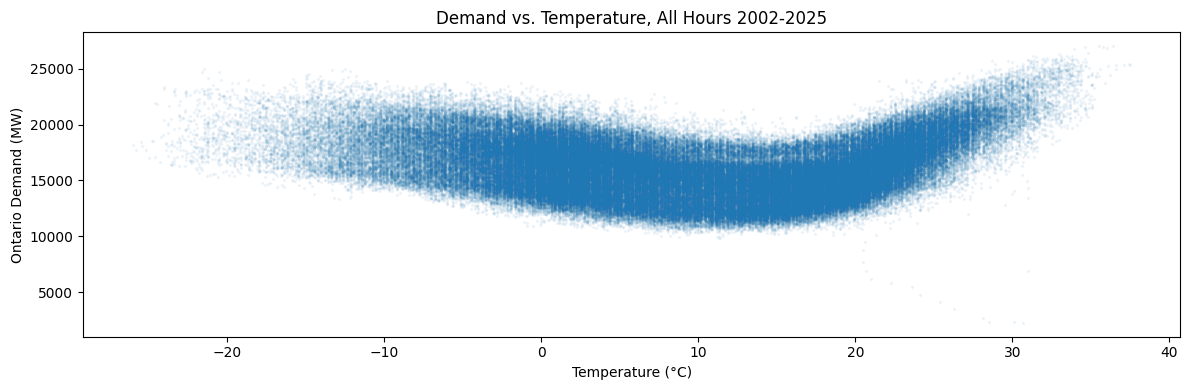

In [40]:
# Classic U-shaped relationship expected: demand rises at BOTH temperature
# extremes (heating in cold, cooling in heat), dips in mild weather.
fig, ax = plt.subplots()
ax.scatter(df['temperature_c'], df['ontario_demand'], s=2, alpha=0.05)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Ontario Demand (MW)')
plt.title('Demand vs. Temperature, All Hours 2002-2025')
plt.tight_layout()
plt.show()

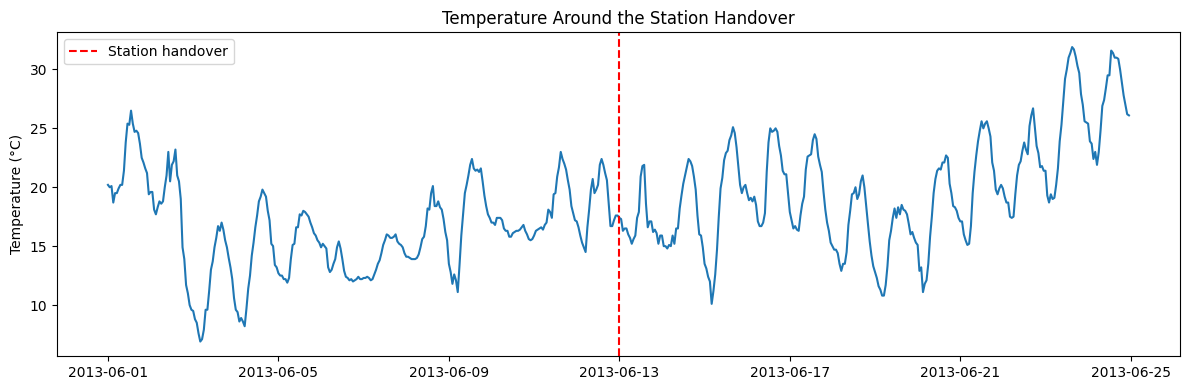

In [41]:
# Check the weather around the crossover point (June 13, 2013) between weather stations
window = df[(df['datetime'] >= '2013-06-01') & (df['datetime'] < '2013-06-25')]

fig, ax = plt.subplots()
ax.plot(window['datetime'], window['temperature_c'])
ax.axvline(pd.Timestamp('2013-06-13'), color='red', linestyle='--', label='Station handover')
plt.title('Temperature Around the Station Handover')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Save the cleaned dataset - COME BACK AT THE END, COULD ONLY KEEP WHAT'S NECESSARY?

This notebook's `df` now includes the missing-value handling (short-gap
interpolation + climatological fill) done above -- that makes it a
genuinely cleaned dataset, distinct from the raw download.

Following the raw / interim / processed split from the project structure:
`data/raw/` stays untouched (the original downloads, never modified, so we
can always redo cleaning differently later without re-downloading), and
this cleaned version belongs in `data/interim/`.

In [42]:
import os
os.makedirs('../data/interim', exist_ok=True)

df.to_csv('../data/interim/cleaned_dataset.csv', index=False)
print(f"Saved {len(df):,} rows to data/interim/cleaned_dataset.csv")


Saved 201,624 rows to data/interim/cleaned_dataset.csv
